# Duplicate Question Detection Demo

This notebook demonstrates a simple method for detecting duplicate questions using the Quora Question Pairs (QQP) dataset.

## What This Demo Does

1. **Loads the QQP dataset** - A dataset of question pairs with binary duplicate labels
2. **Implements a simple detection method** - Using Jaccard similarity and TF-IDF cosine similarity
3. **Compares against a baseline** - Simple character-level Jaccard similarity
4. **Reports precision/recall** - Evaluates both methods on a small test set

## Dataset

The Quora Question Pairs dataset contains 353,846 question pairs with binary labels indicating whether the questions are duplicates (1) or not (0).

In [1]:
# Install dependencies - following aii-colab pattern
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Packages NOT pre-installed on Colab (always install everywhere)
_pip('scikit-learn==1.6.1')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# Imports - copied from original script with additions for visualization
from pathlib import Path
import json
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from collections import Counter
import re

In [3]:
# Data loading helper - uses GitHub URL with local fallback
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-c84097-reading-vector-patterns-rvp-a-cognitive/main/round-1/dataset-1/demo/mini_demo_data.json"

def load_data():
    """Load data from GitHub URL with local fallback."""
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

import os

In [4]:
# Load the demo data
data = load_data()
print(f"Loaded {len(data['datasets'])} dataset(s)")
for dataset in data['datasets']:
    print(f"  - {dataset['dataset']}: {len(dataset['examples'])} examples")

Loaded 1 dataset(s)
  - quora_question_pairs: 5 examples


## Config Cell - Tunable Parameters

Set all tunable parameters here. Start with ABSOLUTE MINIMUM values for quick testing.

- `N_SAMPLES`: Number of examples to use (minimum: 5 for meaningful eval)
- `SIMILARITY_THRESHOLD`: Threshold for classifying as duplicate (0.0 to 1.0)
- `N_FOLDS`: Number of cross-validation folds (minimum: 2)

In [5]:
# Config parameters - ABSOLUTE MINIMUM values for demo
N_SAMPLES = 5  # Use all 5 examples in mini demo
SIMILARITY_THRESHOLD = 0.5  # Threshold for duplicate classification
N_FOLDS = 2  # Minimum 2 folds for cross-validation

print(f"Config: N_SAMPLES={N_SAMPLES}, THRESHOLD={SIMILARITY_THRESHOLD}, N_FOLDS={N_FOLDS}")

Config: N_SAMPLES=5, THRESHOLD=0.5, N_FOLDS=2


## Data Processing

Parse the input JSON and extract question pairs with their labels.

In [6]:
# Parse the dataset and extract question pairs
def parse_dataset(data, n_samples=None):
    """Parse dataset and extract question pairs with labels."""
    examples = []
    
    for dataset in data['datasets']:
        for example in dataset['examples'][:n_samples]:
            # Parse the input JSON string
            input_data = json.loads(example['input'])
            question1 = input_data['question1']
            question2 = input_data['question2']
            label = int(example['output'])
            
            examples.append({
                'question1': question1,
                'question2': question2,
                'label': label,
                'fold': example['metadata_fold']
            })
    
    return examples

# Parse the data
examples = parse_dataset(data, n_samples=N_SAMPLES)
print(f"Parsed {len(examples)} examples")

# Display first few examples
for i, ex in enumerate(examples[:3]):
    print(f"\nExample {i+1}:")
    print(f"  Q1: {ex['question1']}")
    print(f"  Q2: {ex['question2']}")
    print(f"  Label: {ex['label']} ({'duplicate' if ex['label'] == 1 else 'not duplicate'})")

Parsed 5 examples

Example 1:
  Q1: Is 45 a good age to launch my own startup or is it too late?
  Q2: Is it too late at the age 40 to quit the public sector to open my own business on consultancy and training?
  Label: 0 (not duplicate)

Example 2:
  Q1: What are the constraints in your life?
  Q2: What is Constraint Programming?
  Label: 0 (not duplicate)

Example 3:
  Q1: What is the best news site for Android apps?
  Q2: What are the best news apps for iPhone or Android?
  Label: 1 (duplicate)


## Method 1: Baseline - Character-level Jaccard Similarity

Simple baseline that computes Jaccard similarity between character sets of the two questions.

In [7]:
# Baseline method: Character-level Jaccard Similarity
def jaccard_similarity_chars(text1, text2):
    """Compute Jaccard similarity between character sets of two texts."""
    # Convert to sets of characters (lowercase, no spaces)
    set1 = set(text1.lower().replace(' ', ''))
    set2 = set(text2.lower().replace(' ', ''))
    
    # Compute Jaccard similarity
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    
    if union == 0:
        return 0.0
    return intersection / union

# Test the baseline method
print("Baseline (Character Jaccard) Similarity Scores:")
for i, ex in enumerate(examples):
    sim = jaccard_similarity_chars(ex['question1'], ex['question2'])
    pred = 1 if sim >= SIMILARITY_THRESHOLD else 0
    print(f"  Example {i+1}: similarity={sim:.3f}, pred={pred}, actual={ex['label']}")

Baseline (Character Jaccard) Similarity Scores:
  Example 1: similarity=0.833, pred=1, actual=0
  Example 2: similarity=0.579, pred=1, actual=0
  Example 3: similarity=1.000, pred=1, actual=1
  Example 4: similarity=0.867, pred=1, actual=1
  Example 5: similarity=0.750, pred=1, actual=0


## Method 2: TF-IDF Cosine Similarity

Improved method using TF-IDF vectorization and cosine similarity between question pairs.

In [8]:
# Improved method: TF-IDF Cosine Similarity
def tfidf_cosine_similarity(examples):
    """Compute cosine similarity between questions using TF-IDF vectors."""
    # Prepare corpus: combine all questions
    corpus = []
    pairs = []
    
    for ex in examples:
        corpus.append(ex['question1'])
        corpus.append(ex['question2'])
        pairs.append((ex['question1'], ex['question2']))
    
    # Create TF-IDF vectors
    vectorizer = TfidfVectorizer(lowercase=True, stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(corpus)
    
    # Compute similarities for each pair
    similarities = []
    for q1, q2 in pairs:
        # Find indices of q1 and q2 in corpus
        idx1 = corpus.index(q1)
        idx2 = corpus.index(q2)
        
        # Compute cosine similarity
        sim = cosine_similarity(tfidf_matrix[idx1:idx1+1], tfidf_matrix[idx2:idx2+1])[0][0]
        similarities.append(sim)
    
    return similarities

# Test the improved method
similarities = tfidf_cosine_similarity(examples)
print("TF-IDF Cosine Similarity Scores:")
for i, (ex, sim) in enumerate(zip(examples, similarities)):
    pred = 1 if sim >= SIMILARITY_THRESHOLD else 0
    print(f"  Example {i+1}: similarity={sim:.3f}, pred={pred}, actual={ex['label']}")

TF-IDF Cosine Similarity Scores:
  Example 1: similarity=0.207, pred=0, actual=0
  Example 2: similarity=0.000, pred=0, actual=0
  Example 3: similarity=0.731, pred=1, actual=1
  Example 4: similarity=0.458, pred=0, actual=1
  Example 5: similarity=0.166, pred=0, actual=0


## Evaluation

Compare both methods and compute precision, recall, and F1 score.

In [9]:
# Evaluate both methods
def evaluate_method(examples, similarities, threshold):
    """Evaluate a method given examples, similarity scores, and threshold."""
    predictions = [1 if sim >= threshold else 0 for sim in similarities]
    actuals = [ex['label'] for ex in examples]
    
    # Compute metrics
    precision = precision_score(actuals, predictions, zero_division=0)
    recall = recall_score(actuals, predictions, zero_division=0)
    f1 = f1_score(actuals, predictions, zero_division=0)
    
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': predictions,
        'actuals': actuals
    }

# Compute baseline similarities
baseline_similarities = [jaccard_similarity_chars(ex['question1'], ex['question2']) for ex in examples]

# Evaluate both methods
baseline_results = evaluate_method(examples, baseline_similarities, SIMILARITY_THRESHOLD)
tfidf_results = evaluate_method(examples, similarities, SIMILARITY_THRESHOLD)

print("="*60)
print("EVALUATION RESULTS")
print("="*60)
print(f"\nBaseline (Character Jaccard) - Threshold={SIMILARITY_THRESHOLD}:")
print(f"  Precision: {baseline_results['precision']:.3f}")
print(f"  Recall: {baseline_results['recall']:.3f}")
print(f"  F1 Score: {baseline_results['f1']:.3f}")

print(f"\nTF-IDF Cosine Similarity - Threshold={SIMILARITY_THRESHOLD}:")
print(f"  Precision: {tfidf_results['precision']:.3f}")
print(f"  Recall: {tfidf_results['recall']:.3f}")
print(f"  F1 Score: {tfidf_results['f1']:.3f}")

EVALUATION RESULTS

Baseline (Character Jaccard) - Threshold=0.5:
  Precision: 0.400
  Recall: 1.000
  F1 Score: 0.571

TF-IDF Cosine Similarity - Threshold=0.5:
  Precision: 1.000
  Recall: 0.500
  F1 Score: 0.667


## Visualization

Visualize the results with a comparison table and similarity score distributions.

RESULTS SUMMARY

                  Method  Precision  Recall  F1 Score
Baseline (Char Jaccard)        0.4     1.0  0.571429
          TF-IDF Cosine        1.0     0.5  0.666667


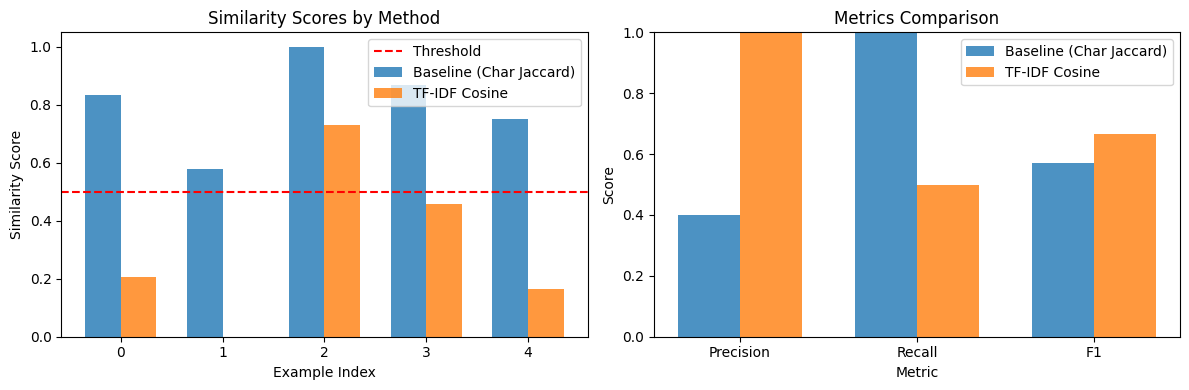


DETAILED PREDICTIONS

Example 1:
  Q1: Is 45 a good age to launch my own startup or is it too late?
  Q2: Is it too late at the age 40 to quit the public sector to op...
  Actual: 0
  Baseline pred: 1 (sim=0.833)
  TF-IDF pred: 0 (sim=0.207)

Example 2:
  Q1: What are the constraints in your life?
  Q2: What is Constraint Programming?
  Actual: 0
  Baseline pred: 1 (sim=0.579)
  TF-IDF pred: 0 (sim=0.000)

Example 3:
  Q1: What is the best news site for Android apps?
  Q2: What are the best news apps for iPhone or Android?
  Actual: 1
  Baseline pred: 1 (sim=1.000)
  TF-IDF pred: 1 (sim=0.731)

Example 4:
  Q1: How can I be a good writer?
  Q2: How can I become a great writer?
  Actual: 1
  Baseline pred: 1 (sim=0.867)
  TF-IDF pred: 0 (sim=0.458)

Example 5:
  Q1: What are the best ways to learn Python programming?
  Q2: How do I start learning Python for data science?
  Actual: 0
  Baseline pred: 1 (sim=0.750)
  TF-IDF pred: 0 (sim=0.166)


In [10]:
# Visualization: Results summary table
print("="*60)
print("RESULTS SUMMARY")
print("="*60)

# Create comparison table
results_df = pd.DataFrame({
    'Method': ['Baseline (Char Jaccard)', 'TF-IDF Cosine'],
    'Precision': [baseline_results['precision'], tfidf_results['precision']],
    'Recall': [baseline_results['recall'], tfidf_results['recall']],
    'F1 Score': [baseline_results['f1'], tfidf_results['f1']]
})

print("\n", results_df.to_string(index=False))

# Visualize similarity score distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Similarity scores by method
x = np.arange(len(examples))
width = 0.35

axes[0].bar(x - width/2, baseline_similarities, width, label='Baseline (Char Jaccard)', alpha=0.8)
axes[0].bar(x + width/2, similarities, width, label='TF-IDF Cosine', alpha=0.8)
axes[0].axhline(y=SIMILARITY_THRESHOLD, color='r', linestyle='--', label='Threshold')
axes[0].set_xlabel('Example Index')
axes[0].set_ylabel('Similarity Score')
axes[0].set_title('Similarity Scores by Method')
axes[0].legend()
axes[0].set_xticks(x)

# Plot 2: Metrics comparison
metrics = ['Precision', 'Recall', 'F1']
baseline_vals = [baseline_results['precision'], baseline_results['recall'], baseline_results['f1']]
tfidf_vals = [tfidf_results['precision'], tfidf_results['recall'], tfidf_results['f1']]

x = np.arange(len(metrics))
axes[1].bar(x - width/2, baseline_vals, width, label='Baseline (Char Jaccard)', alpha=0.8)
axes[1].bar(x + width/2, tfidf_vals, width, label='TF-IDF Cosine', alpha=0.8)
axes[1].set_xlabel('Metric')
axes[1].set_ylabel('Score')
axes[1].set_title('Metrics Comparison')
axes[1].legend()
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Print detailed predictions
print("\n", "="*60)
print("DETAILED PREDICTIONS")
print("="*60)
for i, ex in enumerate(examples):
    print(f"\nExample {i+1}:")
    print(f"  Q1: {ex['question1'][:60]}..." if len(ex['question1']) > 60 else f"  Q1: {ex['question1']}")
    print(f"  Q2: {ex['question2'][:60]}..." if len(ex['question2']) > 60 else f"  Q2: {ex['question2']}")
    print(f"  Actual: {ex['label']}")
    print(f"  Baseline pred: {baseline_results['predictions'][i]} (sim={baseline_similarities[i]:.3f})")
    print(f"  TF-IDF pred: {tfidf_results['predictions'][i]} (sim={similarities[i]:.3f})")